# Quantum Adders Comparison - Performance and Noise Resilience 

In [1]:
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.quantumcircuit import QuantumCircuit
from qiskit.circuit import Gate
from qiskit.circuit.library import CXGate, CCXGate


In [2]:

class Carry(Gate):
    def __init__(self):
        super().__init__(name="Carry", num_qubits=4, params=[])
        qc = QuantumCircuit(4, name=self.name)
        c_in, a, b, c_out = 0, 1, 2, 3
        qc.append(CCXGate(), [a, b, c_out])
        qc.append(CXGate(),  [a, b])
        qc.append(CCXGate(), [c_in, b, c_out])
        self.definition = qc

class Sum(Gate):
    def __init__(self):
        super().__init__(name="Sum", num_qubits=3, params=[])
        qc = QuantumCircuit(3, name=self.name)
        c_in, a, b = 0, 1, 2
        qc.cx(a, b)
        qc.cx(c_in, b)
        self.definition = qc

class RippleCarryAdder(Gate):
    def __init__(self, n: int):
        num_q = 3 * n + 1
        super().__init__(name="RCA", num_qubits=num_q, params=[])
        
        carry    = Carry()
        sum_gate = Sum()
        i_carry  = carry.inverse()
        
        qc = QuantumCircuit(num_q, name=self.name)

        for i in range(0, num_q - 3, 3):
            qc.append(carry, [i, i + 1, i + 2, i + 3])

        qc.cx(num_q - 3, num_q - 2)
        qc.append(sum_gate, [num_q - 4, num_q - 3, num_q - 2])

        for j in range(num_q - 4, 0, -3):
            qc.append(i_carry,  [j - 3, j - 2, j - 1, j])
            qc.append(sum_gate, [j - 3, j - 2, j - 1])

        self.definition = qc

class QFT(Gate):
    def __init__(self, n: int, do_swaps: bool = True):
        self.do_swaps = do_swaps
        super().__init__(name="QFT", num_qubits=n, params=[])
        
        qc = QuantumCircuit(n, name=self.name)
        for j in range(n - 1, -1, -1):
            qc.h(j)
            for k in range(j - 1, -1, -1):
                lam = np.pi / (2.0 ** (j - k))
                qc.cp(lam, k, j)

        if self.do_swaps:
            for i in range(n // 2):
                qc.swap(i, n - i - 1)

        self.definition = qc

class AQFT(Gate):
    def __init__(self, n: int, do_swap: bool = True):
        self.do_swap = do_swap
        super().__init__(name="AQFT", num_qubits=n, params=[])
        
        qc = QuantumCircuit(n, name=self.name)
        m = int(np.ceil(np.log2(n))) 

        for j in range(n - 1, -1, -1):
            qc.h(j)
            for k in range(j - 1, max(j - m, -1), -1):
                lam = np.pi / (2.0 ** (j - k))
                qc.cp(lam, k, j)
                
        if self.do_swap:
            for i in range(n // 2):
                qc.swap(i, n - i - 1)

        self.definition = qc

class QFTDraperAdder(Gate):
    def __init__(self, n: int):
        num_q = 2 * n + 1
        super().__init__(name="QFTDraper", num_qubits=num_q, params=[])
        qc = QuantumCircuit(num_q, name=self.name)
        qr_a = list(range(n))
        qr_b = list(range(n, 2 * n + 1))
        
        qc.append(QFT(n + 1, do_swaps=False), qr_b)
        
        for j in range(n):
            for k in range(n - j + 1):
                lam = np.pi / (2 ** k)
                qc.cp(lam, qr_a[j], qr_b[j + k])
                
        qc.append(QFT(n + 1, do_swaps=False).inverse(), qr_b)
        self.definition = qc

class AQFTDraperAdder(Gate):
    def __init__(self, n: int):
        num_q = 2 * n + 1
        super().__init__(name="AQFTDraper", num_qubits=num_q, params=[])
        
        qc = QuantumCircuit(num_q, name=self.name)
        reg_a = list(range(n))
        reg_b = list(range(n, 2 * n + 1))
        
        qc.append(AQFT(n + 1, do_swap=False), reg_b)
        
        m = int(np.ceil(np.log2(n + 1))) if n > 0 else 0
        for k in range(m + 1):
            lam = np.pi / (2 ** k)
            for j in range(min(n, n - k + 1)):
                qc.cp(lam, reg_a[j], reg_b[j + k])
                
        qc.append(AQFT(n + 1, do_swap=False).inverse(), reg_b)
        
        self.definition = qc

# ---------------------------------------------------------
# Quantum Carry-Lookahead Adder (QCLA)
# Developed by Claude
# ---------------------------------------------------------
def _ptree(n):
    idx, k = {}, 0
    logn = int(np.floor(np.log2(n))) if n >= 1 else 0
    for t in range(1, logn + 1):
        for m in range(1, n // (2 ** t)):
            idx[(t, m)] = k; k += 1
    return idx, k, logn

def _carry_ccx(n, cmap, pmap, ancmap):
    Pidx, _, logn = _ptree(n)
    P = lambda t, m: pmap[m] if t == 0 else ancmap[(t, m)]
    g = []
    
    for t in range(1, logn + 1):
        for m in range(1, n // (2 ** t)):
            g.append((P(t - 1, 2 * m), P(t - 1, 2 * m + 1), P(t, m)))
            
    for t in range(1, logn + 1):
        for m in range(0, n // (2 ** t)):
            g.append((P(t - 1, 2 * m + 1),
                      cmap[2 ** t * m + 2 ** (t - 1) - 1],
                      cmap[2 ** t * m + 2 ** t - 1]))
                      
    if n >= 2:
        for t in range(int(np.floor(np.log2((2 * n) / 3.0))), 0, -1):
            for m in range(1, (n - 2 ** (t - 1)) // (2 ** t) + 1):
                g.append((P(t - 1, 2 * m),
                          cmap[2 ** t * m - 1],
                          cmap[2 ** t * m + 2 ** (t - 1) - 1]))
                          
    for t in range(logn, 0, -1):
        for m in range(1, n // (2 ** t)):
            g.append((P(t - 1, 2 * m), P(t - 1, 2 * m + 1), P(t, m)))
            
    return g

class CarryLookaheadAdder(Gate):
    def __init__(self, n: int):
        Pidx, pk, logn = _ptree(n)
        num_q = 4 * n + 1 + pk
        super().__init__(name="QCLA", num_qubits=num_q, params=[])
        
        qc = QuantumCircuit(num_q, name=self.name)
        
        a = list(range(n))
        b = list(range(n, 2 * n))
        s = list(range(2 * n, 3 * n + 1))
        c = list(range(3 * n + 1, 4 * n + 1))
        panc = list(range(4 * n + 1, 4 * n + 1 + pk))
        
        cmap = c
        pmap = b
        ancmap = {k: panc[v] for k, v in Pidx.items()} if pk > 0 else {}
        cg = _carry_ccx(n, cmap, pmap, ancmap)

        for i in range(n): qc.ccx(a[i], b[i], c[i])         
        for i in range(n): qc.cx(a[i], b[i])                
        for x1, x2, tg in cg: qc.ccx(x1, x2, tg)            
        for i in range(n):                                  
            qc.cx(b[i], s[i])
            if i >= 1: qc.cx(c[i - 1], s[i])
        qc.cx(c[n - 1], s[n])                               
        for x1, x2, tg in reversed(cg): qc.ccx(x1, x2, tg)  
        for i in range(n): qc.cx(a[i], b[i])                
        for i in range(n): qc.ccx(a[i], b[i], c[i])         

        self.definition = qc

In [3]:
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_ibm_runtime.fake_provider import FakeKyiv, FakeAachen

# 1. Import from a fake physical hardware backend
fake_backend = FakeKyiv()
fake_backend2 = FakeAachen()
hardware_noise_model1 = NoiseModel.from_backend(fake_backend)
hardware_noise_model2 = NoiseModel.from_backend(fake_backend2)

# 2. Build custom standard model
custom_noise_model_1 = NoiseModel()
custom_noise_model_1.add_all_qubit_quantum_error(depolarizing_error(0.01, 2), ['cx', 'cp'])
custom_noise_model_2 = NoiseModel()
custom_noise_model_2.add_all_qubit_quantum_error(depolarizing_error(0.01, 3), ['ccx'])

In [4]:
def setup_evaluation_circuit(adder_gate, n, x, y):
    total_qubits = adder_gate.num_qubits
    qc = QuantumCircuit(total_qubits, n + 1)
    
    if adder_gate.name == "RCA":
        # Codificação intercalada do RCA: a_i = 3*i + 1, b_i = 3*i + 2
        for i in range(n):
            if (x >> i) & 1: qc.x(3 * i + 1)
            if (y >> i) & 1: qc.x(3 * i + 2)
    else:
        # Codificação em blocos contíguos para AQFT e QCLA
        for i in range(n):
            if (x >> i) & 1: qc.x(i)          
            if (y >> i) & 1: qc.x(n + i)      
            
    qc.append(adder_gate, range(total_qubits))
    
    if adder_gate.name == "RCA":
        # Os bits de soma substituem o registrador B (3*i + 2) e o carry-out (3*n)
        for i in range(n): qc.measure(3 * i + 2, i)
        qc.measure(3 * n, n) 
    elif adder_gate.name in ["AQFTDraper", "QFTDraper"]:
        # Medição de n qubits (agora contemplando o carry-out em n+i)
        for i in range(n): qc.measure(n + i, i)
    elif adder_gate.name == "QCLA":
        for i in range(n + 1): qc.measure(2 * n + i, i)
        
    return qc



Evaluating environment: Ideal
  RCA: 100.0% success
  AQFT: 85.2% success
  QCLA: 100.0% success

Evaluating environment: Depolarizing (p=0.01)
  RCA: 71.7% success
  AQFT: 79.9% success
  QCLA: 82.2% success

Evaluating environment: Hardware (FakeKyiv)
  RCA: 63.9% success
  AQFT: 76.1% success
  QCLA: 78.7% success

Evaluating environment: Hardware (FakeAachen)
  RCA: 79.5% success
  AQFT: 81.8% success
  QCLA: 95.7% success


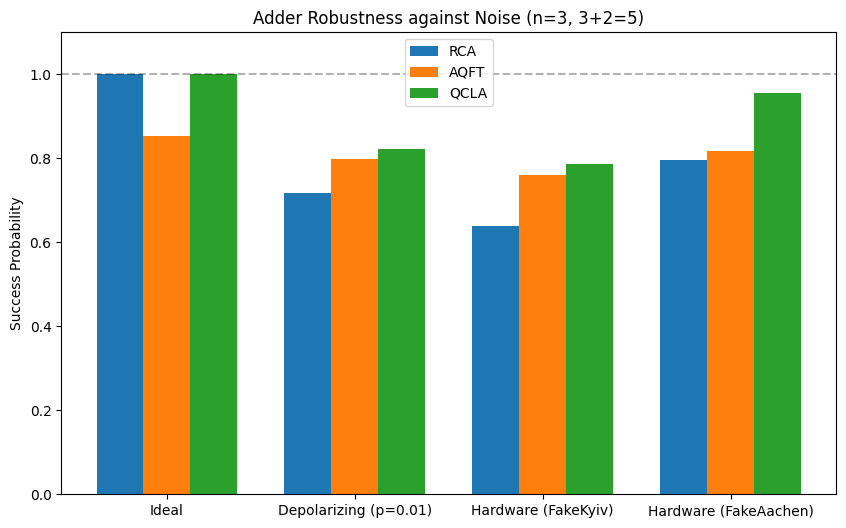

In [8]:
# 1. Initialization
n = 3
x, y = 3, 2  # Target sum = 5 (Binary: 101)
target_bin = bin(x + y)[2:].zfill(n + 1)

adders = {
    "RCA": RippleCarryAdder(n),
    "AQFT": AQFTDraperAdder(n),
    "QCLA": CarryLookaheadAdder(n)
}

noise_environments = {
    "Ideal": None,
    "Depolarizing (p=0.01)": custom_noise_model_1,
    "Hardware (FakeKyiv)": hardware_noise_model1,
    "Hardware (FakeAachen)": hardware_noise_model2
}

results_success_rate = {adder: [] for adder in adders}
env_names = list(noise_environments.keys())

# 2. Execution Loop
shots = 8192
for env_name, noise in noise_environments.items():
    sim = AerSimulator(noise_model=noise)
    print(f"\nEvaluating environment: {env_name}")
    
    for adder_name, gate in adders.items():
        qc = setup_evaluation_circuit(gate, n, x, y)
        qc_transpiled = transpile(qc, sim, optimization_level = 3)
        
        counts = sim.run(qc_transpiled, shots=shots).result().get_counts()
        
        # Calculate success probability
        success_count = counts.get(target_bin, 0)
        success_rate = success_count / shots
        results_success_rate[adder_name].append(success_rate)
        print(f"  {adder_name}: {success_rate * 100:.1f}% success")

# 3. Plotting
x_indices = np.arange(len(env_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
for i, (adder_name, rates) in enumerate(results_success_rate.items()):
    offset = (i - 1) * width
    ax.bar(x_indices + offset, rates, width, label=adder_name)

ax.set_ylabel('Success Probability')
ax.set_title(f'Adder Robustness against Noise (n={n}, {x}+{y}={x+y})')
ax.set_xticks(x_indices)
ax.set_xticklabels(env_names)
ax.axhline(1.0, color='black', linestyle='--', alpha=0.3)
ax.legend()
plt.ylim(0, 1.1)
plt.show()


Analisando arquiteturas para n = 3
Extraindo profundidade do circuito...

  [Simulação] Ambiente: Ideal
    RCA: 100.0% success
    AQFT: 85.5% success
    QCLA: 100.0% success

  [Simulação] Ambiente: Depolarizing (p=0.01)
    RCA: 94.9% success
    AQFT: 80.7% success
    QCLA: 95.3% success

  [Simulação] Ambiente: Hardware (FakeKyiv)
    RCA: 80.2% success
    AQFT: 76.9% success
    QCLA: 80.5% success

  [Simulação] Ambiente: Hardware (FakeAachen)
    RCA: 89.9% success
    AQFT: 84.4% success
    QCLA: 98.2% success

Analisando arquiteturas para n = 4
Extraindo profundidade do circuito...

  [Simulação] Ambiente: Ideal
    RCA: 100.0% success
    AQFT: 95.7% success
    QCLA: 100.0% success

  [Simulação] Ambiente: Depolarizing (p=0.01)
    RCA: 92.6% success
    AQFT: 83.5% success
    QCLA: 94.1% success

  [Simulação] Ambiente: Hardware (FakeKyiv)
    RCA: 80.0% success
    AQFT: 85.9% success
    QCLA: 79.3% success

  [Simulação] Ambiente: Hardware (FakeAachen)
    RCA: 90

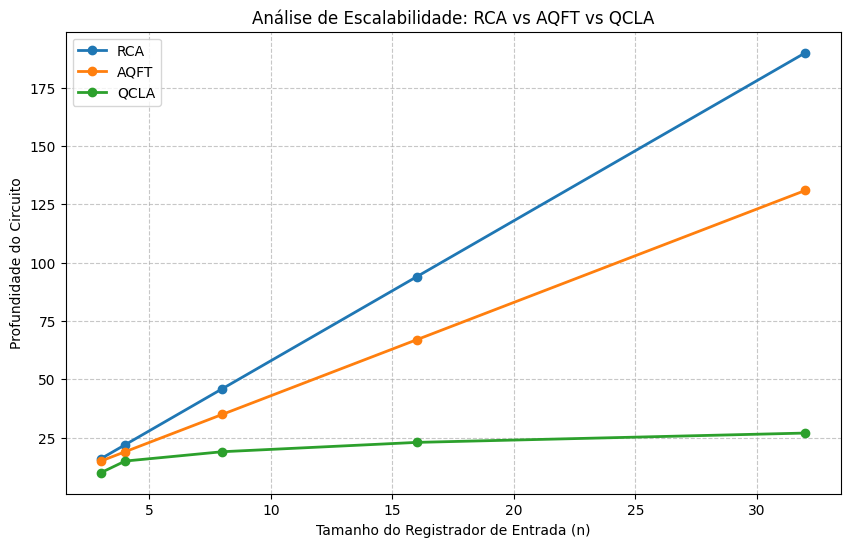

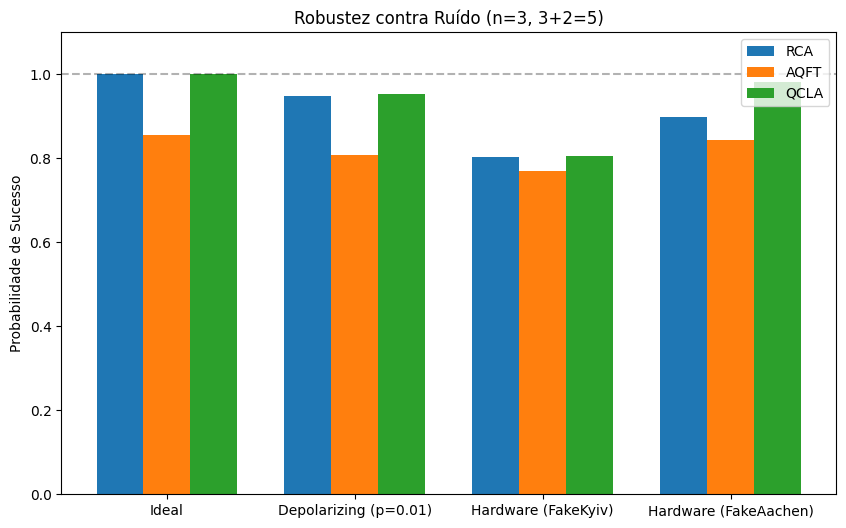

In [6]:
# 1. Initialization
n_values = [3, 4, 8, 16, 32]
x, y = 3, 2  # Target sum = 5 (binário base, ajustado automaticamente com zfill)
shots = 4096

noise_environments = {
    "Ideal": None,
    "Depolarizing (p=0.01)": custom_noise_model_1,
    "Hardware (FakeKyiv)": hardware_noise_model1,
    "Hardware (FakeAachen)": hardware_noise_model2
}

# Estruturas para armazenamento de dados
depth_results = {"RCA": [], "AQFT": [], "QCLA": []}
# Dicionário de sucesso aninhado: results_success_rate[n][adder_name] = [taxas por ambiente]
results_success_rate = {n: {adder: [] for adder in ["RCA", "AQFT", "QCLA"]} for n in n_values if n <= 10}
env_names = list(noise_environments.items())

# 2. Execution Loop
for n in n_values:
    print(f"\n{'='*40}")
    print(f"Analisando arquiteturas para n = {n}")
    print(f"{'='*40}")
    
    target_bin = bin(x + y)[2:].zfill(n + 1)
    
    adders = {
        "RCA": RippleCarryAdder(n),
        "AQFT": AQFTDraperAdder(n),
        "QCLA": CarryLookaheadAdder(n)
    }
    
    # --- PARTE A: Avaliação de Profundidade (Aplica-se a todos os n) ---
    print("Extraindo profundidade do circuito...")
    for adder_name, gate in adders.items():
        qc_depth = QuantumCircuit(gate.num_qubits)
        qc_depth.append(gate, range(gate.num_qubits))
        qc_transpiled_depth = transpile(qc_depth, basis_gates=['u3', 'cx', 'cp', 'ccx'], optimization_level=1)
        depth_results[adder_name].append(qc_transpiled_depth.depth())
        
    # --- PARTE B: Integração com Ruído (Apenas para n <= 10) ---
    if n <= 10:
        for env_name, noise in noise_environments.items():
            print(f"\n  [Simulação] Ambiente: {env_name}")
            sim = AerSimulator(noise_model=noise)
            
            for adder_name, gate in adders.items():
                try:
                    qc = setup_evaluation_circuit(gate, n, x, y)
                    
                    # Filtro para ignorar o UserWarning de sobrescrita de calibração
                    import warnings
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore")
                        qc_transpiled = transpile(qc, sim, basis_gates=['u3', 'cx', 'cp', 'ccx'], optimization_level=1)
                    
                    counts = sim.run(qc_transpiled, shots=shots).result().get_counts()
                    success_count = counts.get(target_bin, 0)
                    success_rate = success_count / shots
                    
                    results_success_rate[n][adder_name].append(success_rate)
                    print(f"    {adder_name}: {success_rate * 100:.1f}% success")
                    
                except Exception as e:
                    # Captura limites de hardware/memória e insere NaN para não quebrar o gráfico
                    results_success_rate[n][adder_name].append(np.nan)
                    print(f"    {adder_name}: Pulado ({type(e).__name__} - Circuito excede capacidade)")
    else:
        print("\n  [Simulação] Pulada (n > 10 excede limite de memória do simulador local).")

# 3. Plotting
# Gráfico 1: Crescimento da Profundidade (Escalabilidade)
plt.figure(figsize=(10, 6))
for name, depths in depth_results.items():
    plt.plot(n_values, depths, marker='o', linewidth=2, label=name)

plt.xlabel('Tamanho do Registrador de Entrada (n)')
plt.ylabel('Profundidade do Circuito')
plt.title('Análise de Escalabilidade: RCA vs AQFT vs QCLA')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Gráfico 2: Taxa de Sucesso (Ruído) para um n específico (ex: n=3)
n_plot = 3
if n_plot in results_success_rate:
    x_indices = np.arange(len(noise_environments))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 6))
    for i, (adder_name, rates) in enumerate(results_success_rate[n_plot].items()):
        offset = (i - 1) * width
        ax.bar(x_indices + offset, rates, width, label=adder_name)

    ax.set_ylabel('Probabilidade de Sucesso')
    ax.set_title(f'Robustez contra Ruído (n={n_plot}, {x}+{y}={x+y})')
    ax.set_xticks(x_indices)
    ax.set_xticklabels(noise_environments.keys())
    ax.axhline(1.0, color='black', linestyle='--', alpha=0.3)
    ax.legend()
    plt.ylim(0, 1.1)
    plt.show()